<a href="https://colab.research.google.com/github/AnibalSJ/GCI_DataScience_AI_Matsuo_Lab/blob/main/lec8_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feature Engineering and Ensemble Learning

**Chapter Introduction**

This notebook accompanies the *Feature Engineering* lecture. It walks through:

1. **Overview of feature engineering** — what it is and why it matters
2. **Transforming numerical variables** — scaling and log transformation
3. **Transforming categorical variables** — label encoding, one-hot encoding, and cross features
4. **Use of domain knowledge** — turning raw data into meaningful features
5. **Ensembling** — bagging, boosting, and the bias-variance tradeoff

A separate session covers model evaluation metrics (MSE, R², precision/recall/F1, ROC-AUC, ...), so those are intentionally not duplicated here.


## Table of contents

- **[1. Overview of Feature Engineering](#1-Overview-of-Feature-Engineering)**
  - 1.1 What is feature engineering
  - 1.2 Why feature engineering matters
  - 1.3 Types of feature engineering
  - 1.4 Classifications of variables
- **[2. Transforming Numerical Variables](#2-Transforming-Numerical-Variables)**
  - 2.1 Scaling (standardization, normalization)
  - 2.2 Log transformation
  - 2.3 Scaling and tree-based models
- **[3. Transforming Categorical Variables](#3-Transforming-Categorical-Variables)**
  - 3.1 Label encoding
  - 3.2 One-hot encoding
  - 3.3 Cross features
- **[4. Use of Domain Knowledge](#4-Use-of-Domain-Knowledge)**
- **[5. Ensembling](#5-Ensembling)**
  - 5.1 What is ensemble learning
  - 5.2 Bagging
  - 5.3 Why does bagging work?
  - 5.4 Random forest
  - 5.5 Boosting
  - 5.6 Why does boosting work?
  - 5.7 Gradient boosting and XGBoost
  - 5.8 Bias-variance tradeoff
  - 5.9 Section summary
- **[6. Key Takeaways](#6-Key-Takeaways)**


## 0. Setup

Run the cell below first to import libraries and load the two datasets used throughout the notebook (California Housing for regression, Breast Cancer for classification).


In [ ]:
# Standard libraries
import numpy as np
import numpy.random as random
import pandas as pd
from pandas import Series, DataFrame
import warnings

# Display up to three decimal places
%precision 3

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set()

# Ignore warnings
warnings.filterwarnings('ignore')

# scikit-learn building blocks used in multiple sections
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.metrics import r2_score, accuracy_score


In [ ]:
# Regression task: California Housing
from sklearn.datasets import fetch_california_housing

california_housing = fetch_california_housing(as_frame=True)
X_housing = california_housing.data
y_housing = california_housing.target

# Classification task: Breast Cancer
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer(as_frame=True)
X_cancer = cancer.data
y_cancer = cancer.target

print('California Housing:', X_housing.shape, '/ target:', y_housing.shape)
print('Breast Cancer    :', X_cancer.shape,  '/ target:', y_cancer.shape)


California Housing: (20640, 8) / target: (20640,)
Breast Cancer    : (569, 30) / target: (569,)


## 1. Overview of Feature Engineering


### 1.1 What is feature engineering

Keywords: bias-variance tradeoff, underfit, overfit, standardization, normalization, nonlinear transformation, encoding, one-hot encoding

**Feature engineering** is the process of *selecting, transforming, or creating input variables* to make your data more meaningful to the model. Well-crafted features (variables) can significantly boost a model's accuracy by exposing relevant relationships that raw data might conceal. On the other hand, poor or redundant features can weaken your model's performance, masking the core patterns you're trying to learn.


### 1.2 Underfit vs. Overfit

**Underfitting** occurs when a model is too simple or when the data lacks crucial signals for it to learn, often leaving the model unable to capture important trends.

When the model underfits, meaning it shows poor generalization, the general approach is to explore adding more features.

Some strategies are:
- Collecting new data to add entirely new features
- Introducing variations in feature calculation periods
- Adding ratios or interactions between existing features

Other techniques, such as data augmentation, are also available and worth exploring if you are interested.

**Overfitting** happens when a model clings too tightly to training data, fitting noise rather than true patterns.

If overfitting is suspected, the opposite approach to underfitting is typically employed: reducing the number of features. Too many features relative to the amount of data can increase the upper limit of generalization error, a phenomenon known as the curse of dimensionality.

Reducing the number of features is aslo referred to as **dimensionality reduction**, which can be classified into two types:

- **Feature Selection**: Choosing a subset of existing features.
- **Feature Extraction**: Transforming the original feature space into a new one.

Principal Component Analysis (PCA), which was previously discussed, is a widely known technique for feature extraction. For feature selection, you can use classes like `RFE` or `RFECV` from the `sklearn.feature_selection` module, though detailed explanations are omitted in this course.

For cases where model interpretability is a priority, feature selection is generally preferred for dimensionality reduction. Refer to the "Recommended Reading on Feature Engineering" section for more resources.







### 1.3 Types of feature engineering

- **Using general-purpose methods** that are not dependent on the problem setting
- **Relying on domain-specific knowledge** related to the problem setting

In this notebook, we will introduce some representative methods that do not require domain-specific knowledge.

More specifically, we will look at two types of general-purpose feature enginnering,

- **Transforming features**: Transform the data for the model to handle inputs easier
- **Creating features**: Make new features to improve model's performance

### 1.4 Classifications of variables

Knowing what *kind* of variable you are working with tells you which transformations even make sense. Variables are usually split into two groups:


- **Quantitiative (Nnumerical) variables**:  difference have meaning, e.g., ratio/interval data.
- **Qualitative (categorical) variables** : represent categories, e.g., ordinal/nominal data.

Below, we are going to look closely into how we generally deal with **numerical vairalbes** in **secsion 2** and **categorical vairalbes** in **secsion 3**.

## 2. Transforming Numerical Variables


### 2.1 Scaling (standardization and normalization)

Scaling methods like **standardization** or **normalization** can be applied to numeric variables when they have different scales and thus prevents non-tree-based models from learning properly.

- **Standardization** — rescale a feature \(x\) so its mean is 0 and its standard deviation is 1:
  $$ x_{\text{std}} = \frac{x - \mu_x}{\sigma_x} $$
- **Normalization (min-max scaling)** — rescale so the minimum is 0 and the maximum is 1:
  $$ x_{\text{norm}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}} $$

Both keep the *shape* of the distribution; they only change its location and width.

Let’s standardize a single column from the iris dataset and look at the before/after summary statistics.


In [ ]:
# Import from scikit-learn
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# Load data
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

# Extract target variables
x = df[['sepal length (cm)']]

# Create and apply StandardScaler
ss = StandardScaler()
x_std = ss.fit_transform(x)

# Compare pre- and post-transformation values
x['sepal length std'] = x_std
display(x)

# Compare pre- and post-transformation (mean and standard deviation)
x.describe().loc[['mean', 'std'], :]

,sepal length (cm),sepal length std
0,5.1,-0.900681
1,4.9,-1.143017
2,4.7,-1.385353
3,4.6,-1.506521
4,5.0,-1.021849
...,...,...
145,6.7,1.038005
146,6.3,0.553333
147,6.5,0.795669
148,6.2,0.432165


,sepal length (cm),sepal length std
mean,5.843333,-4.736952e-16
std,0.828066,1.003350e+00


The transformed column now has mean ≈ 0 and standard deviation ≈ 1, as expected.

Below, we run a small experiment on iris to see *when* scaling actually changes the model: we compare a linear model (logistic regression) and a tree-based model, whose settings are given as follows:

- Explanatory Variable: `sepal length (cm)`
- Target Variable: `target` (iris species, 3 classes)
- Models: Logistic Regression / Decision Tree
- Variable Transformation: With and without standardization
- Evaluation Metric: Accuracy
- Validation Method: Hold-out method

We use `Pipeline` from `sklearn.pipeline`, which can be used to apply multiple modules in sequence. Here, we pass the `StandardScaler` and the individual model.

In [ ]:
# Import from scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

# Preparing data
X = df[['sepal length (cm)']]
y = df.loc[:, "target"]

# Split into training and test datasets
X_train, X_valid, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Prepare models
mods = {
    'LogisticRegression': LogisticRegression(C=0.01, random_state=42),
    'StandardScaler + LogisticRegression': Pipeline([('ss', StandardScaler()), ('model', LogisticRegression(C=0.01, random_state=42))]),
    'DecisonTree': DecisionTreeClassifier(random_state=42),
    'StandardScaler + DecisonTree': Pipeline([('ss', StandardScaler()), ('model', DecisionTreeClassifier(random_state=42))])
}

# Model training and evaluation
results = {}
for mod_name, mod in mods.items():
    mod.fit(X_train, y_train)
    results[(mod_name, 'train')] = round(accuracy_score(y_train, mod.predict(X_train)), 3)
    results[(mod_name, 'valid')] = round(accuracy_score(y_test, mod.predict(X_valid)), 3)

# Organizing the results
pd.Series(results).unstack().iloc[[1, 3, 0, 2]]

,train,valid
LogisticRegression,0.610,0.533
StandardScaler + LogisticRegression,0.705,0.600
DecisonTree,0.771,0.756
StandardScaler + DecisonTree,0.771,0.756


Two things to notice:

- **Logistic regression is sensitive to scale** — performance changes meaningfully when a `StandardScaler` is added in front of it.
- **The decision tree is essentially scale-invariant** — its score barely moves whether the input is standardized or not. We will see *why* in section 2.3.


> **[Let’s try it]**
> - Replace `StandardScaler` with `MinMaxScaler` and see whether it changes the linear model’s score by a similar amount.
> - Add more features (e.g. `petal length (cm)`) and check whether the gap between scaled and unscaled logistic regression grows.


### 2.2 Log transformation


**Logarithmic transformation** is used to correct skewed distribution by applying the $\log$ function. When a variable is **heavily right-skewed** — many small values and a few very large ones (e.g. income, city population) — a model can have trouble using it directly. Applying the (natural) logarithm,
$$
x' = \log(x),
$$
compresses the large values and stretches the small ones, often turning a long-tailed distribution into something much closer to symmetric.

⚠️ `log` is not defined for zeros or negative values, so use `np.log1p(x) = log(1 + x)` if you have zeros, and apply it only to non-negative quantities.

Below we apply a log transform to two skewed columns of the wine dataset and visually compare the distributions before and after. Let's take these columns as examples:
- `color_intensity`: Intensity of color
- `malic_acid`: Concentration of malic acid


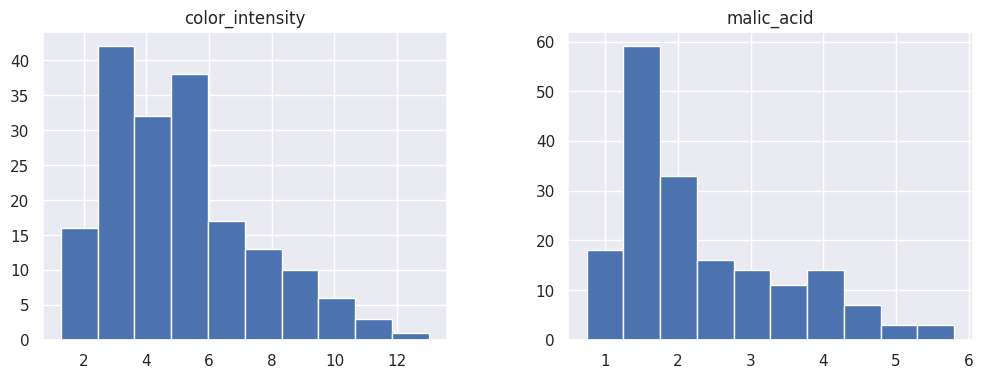

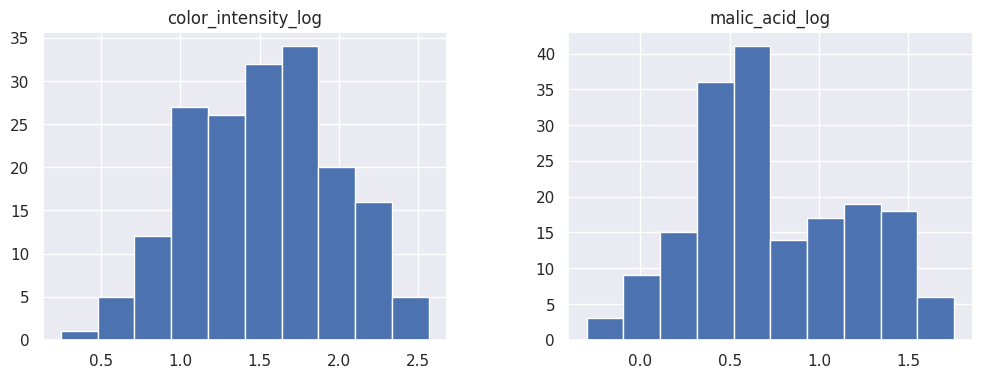

In [ ]:
# Import from scikit-learn
from sklearn.datasets import load_wine

# Load data
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['variety'] = wine.target

# Extract target variables
cols = ['color_intensity', 'malic_acid']
X = df[cols]

# Display original distributions
X.hist(figsize=(12, 4))

# Apply logarithmic transformation
X_log = np.log(X)
cols_log = [s + '_log' for s in cols]
X_log.columns = cols_log

# Display transformed distributions
X_log.hist(figsize=(12, 4))
plt.show()

The skewness in both histograms is much reduced after the log transformation.

Does it actually help downstream classification? Compare the performance of logistic regression using these variables as explanatory variables.

- Explanatory Variables: `color_intensity`, `malic_acid`
- Target Variable: `variety` (wine type, 3 classes)
- Model: Logistic Regression
- Variable Transformation: With and without logarithmic transformation
- Evaluation Metric: F1 Score
- Validation Method: 5-fold Cross-Validation

In [ ]:
# Import from scikit-learn
from sklearn.model_selection import cross_val_score

# Define target variable
target_variable = df['variety']

# Create model
logistic_model = LogisticRegression(random_state=42)

# Train and evaluate model using cross-validation
# Without logarithmic transformation
cv_score_without_log_transform = cross_val_score(logistic_model, X, target_variable, cv=5, scoring='f1_weighted').mean()

# With logarithmic transformation
cv_score_with_log_transform = cross_val_score(logistic_model, X_log, target_variable, cv=5, scoring='f1_weighted').mean()

# Display results
print('Cross-validation score (w/o log transformation): {:.3f}'.format(cv_score_without_log_transform))
print('Cross-validation score (w/ log transformation): {:.3f}'.format(cv_score_with_log_transform))

Cross-validation score (w/o log transformation): 0.768
Cross-validation score (w/ log transformation): 0.797


The log-transformed version gives a higher cross-validated F1 score, confirming that for *linear* models, taming skewness can have a real impact on performance.


> **[Let’s try it]**
> - Try `np.log1p` on a column that contains zeros and check that it no longer raises a warning.
> - Repeat the experiment with a `RandomForestClassifier` and confirm that, unlike logistic regression, the tree-based model is largely indifferent to the log transform.


### 2.3 Scaling has (almost) no effect on tree-based models

Tree-based models (decision trees, random forests, gradient boosting, XGBoost, LightGBM, ...) split the data based on the **rank order** of feature values, not their absolute scale.

Standardizing or min-max-scaling a feature only re-labels the same rank ordering, so the resulting splits — and the resulting model — are essentially identical.


#### <Practice Question 1>

Use the California Housing data (`X_housing`, `y_housing` loaded in Section 0) to compare a **linear model** and a **tree-based model** with and without numerical transformations.



In [ ]:
# --- Solution to Practice Question 1 ---
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

(1) Split the data into train and test with `train_test_split(X_housing, y_housing, test_size=0.2, random_state=0)`.

In [ ]:
# WRITE ME

(2) Train two models on the raw features and record their **test R²**:
- `Ridge(alpha=1.0)`
- `DecisionTreeRegressor(random_state=0, max_depth=6)`


In [ ]:
# WRITE ME

(3) Apply `StandardScaler` to the features (fit on train, transform both train and test). Re-train the two models and compare the test R² to part (2). **Which model is affected by scaling, and which is not? Why?** (revisit Section 2.3 if unsure.)

In [ ]:
# WRITE ME

(4) *(Slightly harder)* A quick look at `X_housing.hist(figsize=(12, 8))` shows that `MedInc`, `AveRooms`, `Population`, and `AveOccup` are heavily right-skewed. Apply `np.log1p` to those four columns **in addition to** the standardization from (3), then re-train the two models. Did the linear model improve more than the tree-based model? Explain why in 1–2 sentences.

In [ ]:
# (4) log1p on skewed columns, then standardized
skewed = ['MedInc', 'AveRooms', 'Population', 'AveOccup']
X_tr_log, X_te_log = X_tr.copy(), X_te.copy()
X_tr_log[skewed] = # WRITE ME
X_te_log[skewed] = # WRITE ME
ss2 = # WRITE ME
ridge_ls = Ridge(alpha=1.0).fit(ss2.transform(X_tr_log), y_tr)
tree_ls  = DecisionTreeRegressor(random_state=0, max_depth=6).fit(ss2.transform(X_tr_log), y_tr)
ridge_ls = r2_score(y_te, ridge_ls.predict(ss2.transform(X_te_log)))
tree_ls  = r2_score(y_te, tree_ls.predict(ss2.transform(X_te_log)))

pd.DataFrame({
    'Ridge test R²':        [ridge_raw, ridge_std, ridge_ls],
    'DecisionTree test R²': [tree_raw,  tree_std,  tree_ls],
}, index=['(2) raw', '(3) standardized', '(4) log + standardized']).round(3)

# Write down your observations:


,Ridge test R²,DecisionTree test R²
(2) raw,0.594,0.618
(3) standardized,0.594,0.618
(4) log + standardized,0.606,0.618


## 3. Transforming Categorical Variables

Categorical variables (e.g., sex, address, product ID, etc) need to be converted into numerical variables in advance.
This process is called **encoding**, and there are various methods available, including:
- **Label Encoding**
- **Count Encoding**
- **Label-Count Encoding**
- **One-Hot Encoding**

In this notebook, we will look at applying **label encoding** and **one-hot encoding** to the categorical variable `embarked` in the Titanic dataset. The `embarked` variable represent the port of embarkation, with three possible values: `C` (Cherbourg), `Q` (Queenstown), and `S` (Southampton).

### 3.1 Label Encoding

**Label encoding** assigns each distinct category a unique integer.


| Index | Embarked  |   →   | Embarked (encoded) |
| --- |--------|-------|-----------|
| 1 | S  |       | 2         |
| 2 | C  |       | 0         |
| 3 | S  |       | 2         |
| 4 | S  |       | 2         |
| 5 | S  |       | 2         |
| 6 | Q  |       | 1         |

- **Pros**: Simple, no increase in feature count, works well with **tree-based models** (the tree can split between any pair of integers).
- **Cons**: For linear/distance-based models it introduces a **fake ordering** — the model might interpret `S (2) > Q (1) > C (0)` as if S were “greater than” C.

Use label encoding when:
- Your downstream model is a tree-based model, **or**
- The categorical variable is genuinely *ordinal* (e.g. `"low", "medium", "high"`).


In [ ]:
# Titanic data (Kaggle-style schema) — loaded directly from a public mirror,
# so the notebook works without Google Drive / Kaggle credentials.
TITANIC_URL = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(TITANIC_URL)

# Extract the Embarked column for the one-hot encoding demo below.
x = df['Embarked']

# Fill missing values with the most frequent value, 'S'.
x = x.fillna('S')

# Inspect the column
x.head(10)


,Embarked
0,S
1,C
2,S
3,S
4,S
5,Q
6,S
7,S
8,S
9,C


In [ ]:
from sklearn.preprocessing import LabelEncoder
# Applying label Encoding
le = LabelEncoder()
encoded = le.fit_transform(x)

pd.DataFrame({'Embarked': x, 'Embarked (encoded)': encoded})

,Embarked,Embarked (encoded)
0,S,2
1,C,0
2,S,2
3,S,2
4,S,2
...,...,...
886,S,2
887,S,2
888,S,2
889,C,0


### 3.2 One-Hot Encoding

**One-hot encoding** creates a separate 0/1 column for each category and sets the column matching the row’s category to 1.

| Index | Embarked  |   →   | S | C | Q |
| --- |--------|-------|-----------|-------------|------------|
| 1 | S  |       | 1         | 0           | 0          |
| 2 | C  |       | 0         | 1           | 0          |
| 3 | S  |       | 1         | 0           | 0          |
| 4 | S  |       | 1         | 0           | 0          |
| 5 | S  |       | 1         | 0           | 0          |
| 6 | Q  |       | 0         | 0           | 1          |

- **Pros**: No fake ordering — every category is symmetric.
- **Cons**: For high-cardinality variables (e.g. product IDs with thousands of distinct values) you get one new column per category, blowing up memory and potentially overfitting.

Below we apply one-hot encoding to the `Embarked` column of the Titanic dataset.


In [ ]:
# Applying One-Hot Encoding
x_ohe = pd.get_dummies(x)

# Verifying the result (First 10 Rows)
x_ohe[:10]

,C,Q,S
0,False,False,True
1,True,False,False
2,False,False,True
3,False,False,True
4,False,False,True
5,False,True,False
6,False,False,True
7,False,False,True
8,False,False,True
9,True,False,False


Many models do not accept `True`/`False` directly, so we cast to integers:


In [ ]:
x_ohe = x_ohe.astype(int)
x_ohe[:10]

,C,Q,S
0,0,0,1
1,1,0,0
2,0,0,1
3,0,0,1
4,0,0,1
5,0,1,0
6,0,0,1
7,0,0,1
8,0,0,1
9,1,0,0


### 3.3 Cross Features

A **cross feature** (or **interaction feature**) is a new feature built from a product (or other simple combination) of two or more existing features:

$$ a, b, c \;\rightarrow\; a \times b, \;\; a \times c, \;\; b \times c, \;\; a \times b \times c, \;\ldots $$

Cross features are useful when the target depends on an *interaction* that a simple model cannot easily learn on its own. A classic real-estate example:

> Rent is high when **room size is large AND distance to station is small**.

A linear model can express “rent grows with room size” and “rent shrinks with distance”, but it cannot easily express that the two combine multiplicatively — unless you hand it the product as a new feature.

- **Pros**: Captures interactions that simple models miss.
- **Cons**: The number of possible cross features explodes combinatorially, which costs memory and can lead to overfitting.

With its shortcmonig noted above, cross features are often used in combination with methods that reduces the number of variables, such as feature selection. We can generate all pairwise products automatically with `PolynomialFeatures(interaction_only=True)`.


Here, we try implementing polynomial feature extraction using the titanic dataset. We pick `Age`, `Fare`, `SibSp`, `Parch`, and `Pclass` as the numeric inputs (treating `Pclass` as numeric here for the demo). Age has missing values, so we fill them with the median first.

Each feature represents:
- `Age`: passenger's age in years.
- `Fare`: ticket fare paid (in British pounds at the time).
- `SibSp`: number of siblings and/or spouses also aboard.
- `Parch`: number of parents and/or children also aboard.
- `Pclass`: passenger class — `1` = first, `2` = second, `3` = third. Strictly speaking this is *ordinal*, but for the polynomial-feature demo we treat it as numeric.


In [ ]:
# Select numeric Titanic columns for the demo (Age has NaNs — impute with median).
num_cols = ['Age', 'Fare', 'SibSp', 'Parch', 'Pclass']
X_num = df[num_cols].copy()
X_num['Age'] = X_num['Age'].fillna(X_num['Age'].median())

print(f'Original numeric features: {X_num.shape[1]}')
X_num.head()


Original numeric features: 5


,Age,Fare,SibSp,Parch,Pclass
0,22.0,7.2500,1,0,3
1,38.0,71.2833,1,0,1
2,26.0,7.9250,0,0,3
3,35.0,53.1000,1,0,1
4,35.0,8.0500,0,0,3


The explanatory variables are composed of 5 numerical variables, which, in combination, yield ${}_{5}\mathrm{C}_2+5 = 15$ features.

Let's confirm this.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
# All pairwise products (interaction_only) — same recipe as 3.3, applied to Titanic.
pf = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
X_pf = pf.fit_transform(X_num)

X_pf_df = pd.DataFrame(X_pf, columns=pf.get_feature_names_out(num_cols))
print(f'After PolynomialFeatures: {X_pf_df.shape[1]} features')
print(f'  = {len(num_cols)} originals + C({len(num_cols)}, 2) = {X_pf_df.shape[1]} total\n')

# Show the new cross-feature columns (skip the 5 originals)
X_pf_df.iloc[:, len(num_cols):].head()


After PolynomialFeatures: 15 features
  = 5 originals + C(5, 2) = 15 total



,Age Fare,Age SibSp,Age Parch,Age Pclass,Fare SibSp,Fare Parch,Fare Pclass,SibSp Parch,SibSp Pclass,Parch Pclass
0,159.5000,22.0,0.0,66.0,7.2500,0.0,21.7500,0.0,3.0,0.0
1,2708.7654,38.0,0.0,38.0,71.2833,0.0,71.2833,0.0,1.0,0.0
2,206.0500,0.0,0.0,78.0,0.0000,0.0,23.7750,0.0,0.0,0.0
3,1858.5000,35.0,0.0,35.0,53.1000,0.0,53.1000,0.0,1.0,0.0
4,281.7500,0.0,0.0,105.0,0.0000,0.0,24.1500,0.0,0.0,0.0


> **[Let’s try it]**
> - Compare logistic regression performance on `X` vs `X_pf_df`. Did the additional cross features help, or did they introduce overfitting?
> - Try `PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)` to add squared terms as well, and see how the feature count and performance change.


#### <Practice Question 2>

Re-use the Titanic dataframe `df` loaded in Section 3.2.

(1) Apply both **label encoding** and **one-hot encoding** to the `Embarked` column (fill missing values with `'S'` first). For each encoding, briefly explain which one you would prefer when feeding `Embarked` into (a) a logistic regression, and (b) a decision tree.


In [ ]:
# --- Solution to Practice Question 2 ---
from sklearn.preprocessing import LabelEncoder

emb = df['Embarked'].fillna('S')

# (1) Embarked: both encodings
# WRITE ME

(2) Apply one-hot encoding to the `Sex` column.

In [ ]:
# WRITE ME

(3) Create a **cross feature** by combining `Sex` and `Embarked` into a single string label (e.g. `"female_S"`, `"male_C"`, ...), then one-hot encode that combined column.

In [ ]:
# (3) Sex × Embarked cross feature
df['Sex_Embarked'] = df['Sex'] + '_' + emb
sex_emb_ohe = pd.get_dummies(df['Sex_Embarked'], prefix='SexEmb').astype(int)

print('(1) Embarked label (first 6):', emb_label[:6].tolist())
print('    Embarked one-hot columns:', list(emb_ohe.columns))
print('(2) Sex one-hot columns       :', list(sex_ohe.columns))
print('(3) Sex×Embarked one-hot      :', list(sex_emb_ohe.columns))

(1) Embarked label (first 6): [2, 0, 2, 2, 2, 1]
    Embarked one-hot columns: ['Embarked_C', 'Embarked_Q', 'Embarked_S']
(2) Sex one-hot columns       : ['Sex_female', 'Sex_male']
(3) Sex×Embarked one-hot      : ['SexEmb_female_C', 'SexEmb_female_Q', 'SexEmb_female_S', 'SexEmb_male_C', 'SexEmb_male_Q', 'SexEmb_male_S']


In [ ]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Sex_Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,male_S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,female_C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,female_S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,female_S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,male_S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q,male_Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,male_S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S,male_S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S,female_S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C,female_C


(4) Compute the survival rate (`Survived` mean) for each `Sex_Embarked` group with `df.groupby('Sex_Embarked')['Survived'].mean()`. Which combination has the highest survival rate, and which has the lowest? Is the gap between them larger than the gap you would get from `Sex` alone or from `Embarked` alone? Use your numbers to justify the answer.

In [ ]:
# (4) Survival rate per Sex × Embarked, then gap comparison
sr = df.groupby('Sex_Embarked')['Survived'].agg(['mean','count']).rename(
    columns={'mean':'survival_rate','count':'n'}
).sort_values('survival_rate', ascending=False)
print()
print('(4) Survival rate per Sex × Embarked:')
print(sr.round(3))

gap_sex   = df.groupby('Sex')['Survived'].mean()
gap_emb   = df.groupby('Embarked')['Survived'].mean()
print()
print(f'Gap by Sex only       : {gap_sex.max() - gap_sex.min():.3f}')
print(f'Gap by Embarked only  : {gap_emb.max() - gap_emb.min():.3f}')
print(f'Gap by Sex × Embarked : {sr["survival_rate"].max() - sr["survival_rate"].min():.3f}')
# Discussion (1): For a logistic regression, prefer one-hot — label encoding
# injects a fake order between the three ports. For a decision tree, label
# encoding is fine because trees split on rank, not magnitude.
# Discussion (4): female_C ≈ 88% (highest) vs male_Q ≈ 7% (lowest) — a gap
# of ~0.80. That is much larger than the Sex-only gap (~0.55) or the
# Embarked-only gap (~0.22) — the cross feature surfaces an interaction
# neither column captures alone.
# Caveat: Q has only ~77 passengers total (41 male_Q), so its rate is less
# statistically stable than C and S — keep an eye on the `n` column.



(4) Survival rate per Sex × Embarked:
              survival_rate    n
Sex_Embarked                    
female_C              0.877   73
female_Q              0.750   36
female_S              0.693  205
male_C                0.305   95
male_S                0.175  441
male_Q                0.073   41

Gap by Sex only       : 0.553
Gap by Embarked only  : 0.217
Gap by Sex × Embarked : 0.804


## 4. Use of Domain Knowledge

So far we have transformed and combined features in fairly mechanical ways. The single biggest lever in feature engineering, though, is **domain knowledge** — using expertise about the problem to create variables that are *directly related to the prediction target*.

In this notebook, we try three domain-knowledge based feature engineering on the Titanic dataset.

- **Passenger title** — extract the title (`Mr.`, `Mrs.`, `Miss.`, `Master.`, ...) hidden in the `Name` string. Titles carry information about gender, age class, and social status, all of which were strongly predictive of survival.
- **Sex × Class** — combine `Sex` and `Pclass` into a single label, motivated by the *"women and children first, especially in first class"* evacuation rule.
- **Family size** — collapse `SibSp` and `Parch` into a single `FamilySize` quantity, motivated by the idea that what really mattered during the evacuation was whether the family could stay together.

Below, we implement the former two; the last one is left to you as a Practice Question.


### 4.1 Title extraction from `Name`


In [ ]:
def extract_title(name):
    # "Braund, Mr. Owen Harris"
    after_comma = name.split(',', 1)[1]    # ' Mr. Owen Harris'
    title = after_comma.split('.', 1)[0]   # ' Mr'
    return title.strip()                   # 'Mr'


# Extract titles
df['Title'] = df['Name'].apply(extract_title)

# Check unique titles
df['Title'].unique()

array(['Mr', 'Mrs', 'Miss', 'Master', 'Don', 'Rev', 'Dr', 'Mme', 'Ms',
       'Major', 'Lady', 'Sir', 'Mlle', 'Col', 'Capt', 'the Countess',
       'Jonkheer'], dtype=object)

Some unfamiliar titles may appear. Let's check their frequencies.


In [ ]:
title_counts = df['Title'].value_counts()
print(title_counts)

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64


We categorize rare titles together and merge variants like `Mlle` / `Ms` / `Mme` into their canonical forms.


In [ ]:
# Combine rare titles with low frequencies into a single category called "Rare"
rare_titles = title_counts[title_counts < 10].index  # Titles appearing fewer than 10 times are categorized as "Rare"
df['Title'] = df['Title'].replace(rare_titles, 'Rare')
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

Then we one-hot encode the cleaned-up `Title` column and append it to the dataframe.


In [ ]:
# Create dummy variables for titles
title_dummies = pd.get_dummies(df['Title'], prefix='Title')

# Convert dummy variables from True/False to 0/1
title_dummies = title_dummies.astype(int)

# Combine dummy variables with the dataframe
df = pd.concat([df, title_dummies], axis=1)

# Drop unnecessary columns
df.drop(['Name', 'Title'], axis=1, inplace=True)

Finally, verify the new feature columns were added:


In [ ]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Sex_Embarked,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,1,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,male_S,0,0,1,0,0
1,2,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C,female_C,0,0,0,1,0
2,3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,female_S,0,1,0,0,0
3,4,1,1,female,35.0,1,0,113803,53.1000,C123,S,female_S,0,0,0,1,0
4,5,0,3,male,35.0,0,0,373450,8.0500,NaN,S,male_S,0,0,1,0,0


The new `Title_Master`, `Title_Miss`, `Title_Mr`, `Title_Mrs`, `Title_Rare` columns are now ready to be fed to a classifier — and tend to give a clear boost over using `Sex` and `Age` alone.

> **[Let’s try it]**
> - Pick another domain you know well (sports, finance, retail, healthcare, ...) and list three raw variables you would expect to see, together with three domain-knowledge features you would derive from them.


### 4.2 Combining variables based on domain knowledge: `Sex` × `Pclass`

A second domain-knowledge insight about the Titanic disaster: the *"women and children first"* protocol was applied — and was applied **most consistently in first-class cabins**, which were closer to the boat deck. Knowing this, we expect the **joint distribution of `Sex` and `Pclass`** to be far more informative about survival than either column on its own.

We encode that domain insight by *combining the two columns into a single label*:

$$ \text{Sex\_Pclass} = \text{Sex} \;\Vert\; \text{Pclass} $$


In [ ]:
# Combine Sex and Pclass into one label, then look at the survival rate per group
df['Sex_Pclass'] = df['Sex'] + '_' + df['Pclass'].astype(str)

df.groupby('Sex_Pclass')['Survived'].agg(['mean', 'count']).rename(
    columns={'mean': 'survival_rate', 'count': 'n_passengers'}
).sort_values('survival_rate', ascending=False)


,survival_rate,n_passengers
Sex_Pclass,,
female_1,0.968085,94
female_2,0.921053,76
female_3,0.500000,144
male_1,0.368852,122
male_2,0.157407,108
male_3,0.135447,347


The gap is **dramatic** — `female_1` (1st-class women) survive at ≈97%, while `male_3` (3rd-class men) survive at ≈14%. Neither `Sex` nor `Pclass` alone shows anywhere near this spread. That is the *whole point* of using domain knowledge to construct features: the historian's "women first, especially in first class" insight translates directly into a single column that captures most of the survival signal.

Finally we one-hot encode the combined label so a model can consume it:


In [ ]:
# One-hot encode the combined label
sex_pclass_dummies = pd.get_dummies(df['Sex_Pclass'], prefix='SexPclass').astype(int)
df = pd.concat([df, sex_pclass_dummies], axis=1)

sex_pclass_dummies.head()


,SexPclass_female_1,SexPclass_female_2,SexPclass_female_3,SexPclass_male_1,SexPclass_male_2,SexPclass_male_3
0,0,0,0,0,0,1
1,1,0,0,0,0,0
2,0,0,1,0,0,0
3,1,0,0,0,0,0
4,0,0,0,0,0,1


Compare this with the mechanical `PolynomialFeatures` approach from Section 3.3: that would have built `Sex × Pclass` only if `Sex` was already one-hot encoded *and* the right pair of indicator columns happened to be multiplied. Here, **the choice of which two columns to combine was driven by domain knowledge, not by enumeration** — and the resulting feature is interpretable on its own.


#### <Practice Question 3>

The Titanic data has two columns describing family composition:

- `SibSp` — number of siblings / spouses aboard
- `Parch` — number of parents / children aboard

Domain knowledge about the disaster suggests that what really mattered was **whether the family could stay together during evacuation**, which depends on the *total* family size rather than the breakdown into siblings vs parents. Use this insight to build new features and inspect them:

(1) Create `FamilySize = SibSp + Parch + 1` (the `+ 1` includes the passenger themselves).

(2) Create a binary `IsAlone` flag that is 1 when `FamilySize == 1` and 0 otherwise.


In [ ]:
# --- Solution to Practice Question 3 ---

# (1)(2) Family-related features
df['FamilySize'] = # WRITE ME
df['IsAlone']    = # WRITE ME


(3) Group by `FamilySize` and compute the mean of `Survived` per group. Plot or print the result.

            survival_rate    n
FamilySize                    
1                   0.304  537
2                   0.553  161
3                   0.578  102
4                   0.724   29
5                   0.200   15
6                   0.136   22
7                   0.333   12
8                   0.000    6
11                  0.000    7


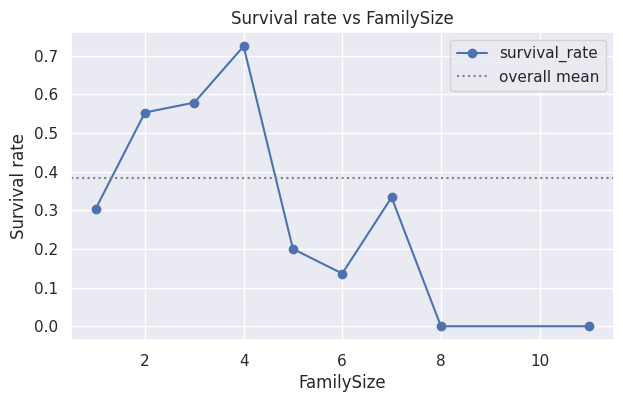

In [ ]:
# (3) Survival rate by FamilySize
sr = # WRITE ME
print(sr.round(3))

# WRITE THE VISUALIZATION CODE

(4) **Discuss**: is the relationship between `FamilySize` and survival monotonic, or is there a "sweet spot"? What might explain the pattern you see?

In [ ]:
# WRITE DOWN YOUR DISCUSSION

(5) *(Optional)* Train a `LogisticRegression` or `DecisionTreeClassifier` on `Survived` using `[Pclass, Sex (encoded), Age (imputed), Fare]` first, then add `FamilySize` and `IsAlone`. Does the test accuracy improve?

> *Hint:* re-use `df` that was loaded in Section 3.2 — it still contains `SibSp` and `Parch`.


In [ ]:
# (5) Optional: does adding family features improve a logistic-regression baseline?
from sklearn.model_selection import cross_val_score

X_base = # WRITE ME
X_aug = # WRITE ME
y_tt  = df['Survived']

base = cross_val_score(LogisticRegression(max_iter=2000), X_base, y_tt, cv=5).mean()
aug  = cross_val_score(LogisticRegression(max_iter=2000), X_aug,  y_tt, cv=5).mean()
print(f'5-fold CV accuracy without family features: {base:.4f}')
print(f'5-fold CV accuracy with family features:    {aug:.4f}')
# Adding the family features typically lifts CV accuracy by ~1 percentage point.


5-fold CV accuracy without family features: 0.7868
5-fold CV accuracy with family features:    0.7935


Notice the clear non-monotonic pattern:

- **Solo passengers (`FamilySize = 1`)** have a low survival rate (~30%).
- **Small families (2–4)** have the highest survival rate (~55–72%).
- **Large families (5+)** drop back down sharply, presumably because keeping a large group together during the evacuation was harder.

Neither `SibSp` nor `Parch` alone exhibits this U-shape — it only emerges once you sum them. That is the whole point of cross features.


## 5. Ensembling
Keywords: ensemble learning, bagging, boosting, bootstrap, AdaBoost, random forest, gradient boosting, XGBoost

So far each model we built was a *single* algorithm trained once. **Ensemble learning** is the idea that combining many imperfect models can give you a model that is stronger than any individual one.


### 5.1 What is ensemble learning

The basic recipe:

1. Train **multiple models** (possibly of the same type, possibly different).
2. **Aggregate** their predictions — by majority vote for classification, or averaging for regression.

Two major families dominate practice:

- **Bagging** — train each model independently on a different random resample, then average.
- **Boosting** — train each model in sequence, each one focusing on the errors of the previous ones.

We cover both below.


### 5.2 Bagging (bootstrap aggregating)

**Bagging** stands for *bootstrap aggregating*. The procedure:

1. Take the training set of size \(n\).
2. Draw **with replacement** \(n\) samples — this is called a *bootstrap resample*. Repeat \(B\) times to get \(B\) resampled datasets.
3. Train one model on each resample, producing \(B\) models.
4. **Aggregate** their predictions (majority vote / average).

Each individual model is a bit weaker because it only sees a noisy subset, but the *combined* model is often much stronger.

![comment](https://qiita-user-contents.imgix.net/http%3A%2F%2Fcse-wiki.unl.edu%2Fwiki%2Fimages%2F5%2F54%2FCombining_classifiers_overview.png?ixlib=rb-4.0.0&auto=format&gif-q=60&q=75&s=2169aa16c80bb32cbae9d7e61221e4a5)

Reference URL: https://qiita.com/nirperm/items/318d7e210c059373f8d2




#### 5.2.1 Bagging Example (1): kNN x Bagging

As an example of implementing bagging, let's take a look at the breast cancer dataset again and build a model with the k-NN algorithm. The `BaggingClassifier` class from the `sklearn.ensemble` module is used.

For regression tasks, refer to the Scikit-learn documentation for the corresponding class.


In [ ]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

# Load data
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)

# Checking the original number of variables
original_feature_count = X.shape[1]
print("Original number of variables: {}".format(original_feature_count))
X.head()

Original number of variables: 30


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
# Import from scikit-learn
from sklearn.ensemble import BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Split into training and test datasets
X_train, X_test, y_train, y_test = train_test_split(
    X_cancer, y_cancer, stratify=y_cancer, random_state=66)

# Setting up the k-NN model and its bagging configuration
models = {
    'kNN': KNeighborsClassifier(),
    'kNN + bagging': BaggingClassifier(KNeighborsClassifier(), n_estimators=100, random_state=0)
}
# Model construction
scores = pd.DataFrame(columns=["train_score", "test_score"], index=models.keys())
for i, (model_name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)
    scores["train_score"][i] = model.score(X_train, y_train)
    scores["test_score"][i] = model.score(X_test, y_test)

scores

,train_score,test_score
kNN,0.948357,0.923077
kNN + bagging,0.950704,0.937063


In the example above,
- `n_estimators`: set to 100, meaning that 100 k-NN models are used for bagging

The training score (`train_score`) remains roughly the same, while the test score (`test_score`) shows an improvement.

The `BaggingClassifier` class also includes parameters such as
- `max_samples` (default: 1.0): specifies the proportion of the original dataset to extract during bootstrapping. e.g., setting this to 0.5 means 50 samples are drawn from a dataset of 100.
- `max_features` (default: 1.0): specifies the proportion of features sampled, with 0.5 indicating that half of all features are used for training each model.

Using only a subset of the data can introduce feature diversity for each sample, helping reduce overfitting in models that are prone to it.

Bagging tends to lift the test score because the averaged predictions are less sensitive to the quirks of any single resample.

> **[Let’s try it]**
> - Try `BaggingClassifier(KNeighborsClassifier(), n_estimators=10)` and `n_estimators=500`. Where does the improvement plateau?
> - Replace `KNeighborsClassifier` with a deep `DecisionTreeClassifier`. Does bagging help more or less when the base learner is already very flexible?


#### <Practice Question 4>

Run the following classifiers on the breast cancer dataset, with and without `BaggingClassifier` (`n_estimators=100`), and report which one benefits most from bagging in your run:

- `LogisticRegression(max_iter=10000)`
- `DecisionTreeClassifier(random_state=0)`
- `KNeighborsClassifier()`


In [ ]:
# --- Solution to Practice Question 4 ---
from sklearn.ensemble import BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier

X_tr, X_te, y_tr, y_te = # WRITE ME

base_models = {
    'LogisticRegression': LogisticRegression(max_iter=10000),
    # WRITE THE REST
}

rows = []
for name, base in base_models.items():
    # WRITE ME
    base_score = # WRITE ME
    bag = # WRITE ME
    bag_score = # WRITE ME
    rows.append({
        'base model':   name,
        'no bagging':   base_score,
        'bagging x100': bag_score,
        'lift':         bag_score - base_score,
    })

pd.DataFrame(rows).set_index('base model').round(4)

# WRITE DOWN YOUR OBSERVATIONS

,no bagging,bagging x100,lift
base model,,,
LogisticRegression,0.9441,0.9441,0.0000
DecisionTree,0.8951,0.9510,0.0559
kNN,0.9231,0.9371,0.0140


#### 5.2.2 Bagging example (2): Random Forest

A **random forest** is bagging applied to decision trees, with one extra twist: at each split, only a random subset of features is considered as candidates for splitting. This forces the trees to look different from one another — without it, a single strong feature would dominate the first split of every tree and the trees would all look the same.

Below we run **RandomForestRegressor** and **GradientBoostingRegressor** on the California Housing dataset (we will discuss the boosting one in section 5.5).


In [ ]:
# Import from scikit-learn
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Split into training and test datasets
X_train, X_test, y_train, y_test = train_test_split(
    X_housing, y_housing, random_state=66)

# Configuring parameters for Random Forest and Gradient Boosting
models = {
    'RandomForest': RandomForestRegressor(random_state=0),
    'GradientBoost': GradientBoostingRegressor(random_state=0)
}

# Model configuration
scores = {}
for model_name, model in models.items():
    model.fit(X_train, y_train)
    scores[(model_name, 'train_score')] = model.score(X_train, y_train)
    scores[(model_name, 'test_score')] = model.score(X_test, y_test)

# Display results (R2 score)
pd.Series(scores).unstack()

,test_score,train_score
GradientBoost,0.795131,0.808224
RandomForest,0.812549,0.972619


#### Feature importance

Tree-based ensembles expose a `feature_importances_` attribute that ranks features by how much they contributed to splits across the whole forest.


<Axes: >

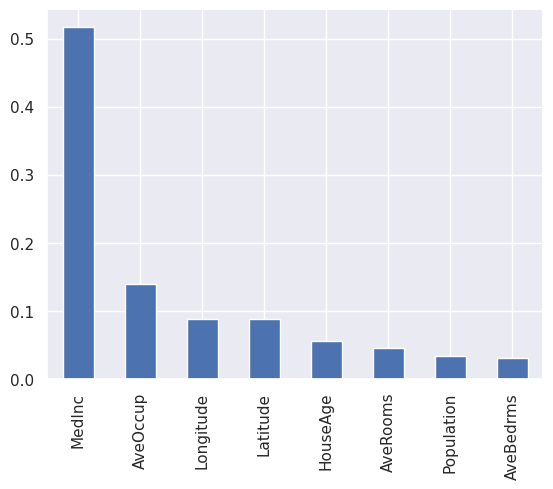

In [ ]:
# Accessing feature_importances_ attribute
s = pd.Series(models['RandomForest'].feature_importances_,
              index=X_housing.columns)

# Displaying the values in descending order
s.sort_values(ascending=False).plot.bar(color='C0')

For reference, the housing dataset includes a textual description of each column via the `DESCR` attribute:


In [ ]:
# Scikit-learn sample data contains explanatory text about the dataset as instance variables
print(california_housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

### 5.5 Boosting

**Boosting** flips the bagging idea on its head: instead of training models independently, boosting trains them **sequentially**:

1. Train a weak model on the data.
2. Check which examples it got **wrong**.
3. Reweight those examples (or fit the *residual error*), then train another model.
4. Repeat. Aggregate the models at the end.


![comment](https://cdn-ak.f.st-hatena.com/images/fotolife/S/St_Hakky/20170728/20170728171209.jpg)

Reference URL: https://cdn-ak.f.st-hatena.com/images/fotolife/S/St_Hakky/20170728/20170728171209.jpg


Examples: **AdaBoost**, **Gradient Boosting**, **XGBoost**, **LightGBM**, ...

Below: a standalone decision tree vs an AdaBoost regressor using a decision tree as the base learner.


In [ ]:
# Import from scikit-learn
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor

# Split into training and test datasets
X_train, X_test, y_train, y_test = train_test_split(
    X_housing, y_housing, random_state=66)

# Configuring parameters for a decision tree and AdaBoostRegressor
models = {
    'Decision tree': DecisionTreeRegressor(random_state=0),
    # Specify the base model in the `estimator` argument (a decision tree is used here, but other models are also applicable)
    'AdaBoost': AdaBoostRegressor(estimator=DecisionTreeRegressor(), random_state=0)
}

# Model configuration
scores = {}
for model_name, model in models.items():
    model.fit(X_train, y_train)
    scores[(model_name, 'train_score')] = model.score(X_train, y_train)
    scores[(model_name, 'test_score')] = model.score(X_test, y_test)

# Display results (R2 score)
pd.Series(scores).unstack()

,test_score,train_score
AdaBoost,0.821205,0.999373
Decision tree,0.613043,1.000000


Switching from a single tree to AdaBoost typically lifts the test score substantially — the sequence of trees corrects errors that any single tree could not.

> **[Let’s try it]**
> - Vary `n_estimators` for `AdaBoostRegressor`. Does performance keep improving, or does it eventually saturate / regress?
> - Compare AdaBoost with `random_state=66` vs `random_state=0` train/test splits. How much does the score depend on the split?


#### <Practice Question 5>

Compare a single `DecisionTreeRegressor(max_depth=3)` against `AdaBoostRegressor(DecisionTreeRegressor(max_depth=3), n_estimators=200)` on the California Housing data. Report the train and test R².


In [ ]:
# --- Solution to Practice Question 5 ---
from sklearn.ensemble import AdaBoostRegressor

X_tr, X_te, y_tr, y_te = # WRITE ME

dt = # WRITE ME
ada = # WRITE ME

pd.DataFrame({
    'train R²': [dt.score(X_tr, y_tr), ada.score(X_tr, y_tr)],
    'test R²':  [dt.score(X_te, y_te), ada.score(X_te, y_te)],
}, index=['DecisionTree(depth=3)', 'AdaBoost (200 trees)']).round(3)
# Observation: a single depth-3 tree gets test R² ~0.54.
# Surprisingly, AdaBoost(200) here actually does WORSE (~0.44). The reason:
# AdaBoostRegressor's default 'linear' loss is sensitive to outliers in the
# housing data, and at 200 estimators the cumulative correction overshoots.
# Real-world boosting is usually done with GradientBoosting (Section 5.7)
# or XGBoost — those *do* close the bias gap reliably. Try replacing
# `AdaBoostRegressor(...)` with `GradientBoostingRegressor(n_estimators=200,
# max_depth=3, random_state=0)` and you should see test R² jump to ~0.81.


,train R²,test R²
DecisionTree(depth=3),0.531,0.539
AdaBoost (200 trees),0.424,0.442


### 5.7 Gradient boosting and XGBoost

**Gradient boosting** generalizes AdaBoost: instead of reweighting examples, it directly trains each new tree to predict the *gradient of the loss* at the current ensemble’s predictions (which, for squared loss, is just the residual). **XGBoost** is a popular, highly optimized implementation with regularization, parallelism, and early stopping.

Each tree is shallow (depth ≈ 3–8) and **predicts the residual** of the running sum so far. The final prediction is the **sum** of all tree outputs.


In [ ]:
# Importing XGBoost
from xgboost import XGBRegressor

# Creating an instance of XGBoost
reg = XGBRegressor(n_estimators=100, random_state=0)
reg.fit(X_train, y_train)  # Training
y_pred = reg.predict(X_test)  # Prediction

# Display results (R2 score)
print(f"Test score: {r2_score(y_test, y_pred): .3f}")

Test score:  0.841


**Early stopping** with XGBoost: train many rounds, but watch performance on a validation set and stop as soon as it stops improving. This is the practical antidote to the “boosting overfits with too many rounds” caveat above.


In [ ]:
# Running this cell will produce many output lines, so we configure Google Colab to reduce the display size
from IPython.display import Javascript
display(Javascript('''google.colab.output.setIframeHeight(0, true, {maxHeight: 300})'''))

# Split X_train and y_train further into training and validation datasets
X_train_split, X_valid, y_train_split, y_valid = train_test_split(X_train, y_train, test_size=0.2, random_state=0)

# Set the number of boosting rounds to 10 times the previous value (1000)
# Increasing the number of boosting rounds without using `early_stopping_rounds` increases the risk of overfitting alongside potential accuracy improvement
reg = XGBRegressor(n_estimators=1000,
                   eval_metric='rmse',  # Specify the evaluation metric for early stopping
                   early_stopping_rounds=10,  # Specify the number of rounds without improvement before stopping
                   random_state=0)

reg.fit(X_train_split, y_train_split,
        eval_set=[(X_valid, y_valid)])  # Specify the validation dataset in `eval_set`

y_pred = reg.predict(X_test) # Prediction

# Display results (R2 score)
print(f"Test score: {r2_score(y_test, y_pred): .3f}")

<IPython.core.display.Javascript object>

[0]	validation_0-rmse:0.94717
[1]	validation_0-rmse:0.81703
[2]	validation_0-rmse:0.72572
[3]	validation_0-rmse:0.66901
[4]	validation_0-rmse:0.62957
[5]	validation_0-rmse:0.60705
[6]	validation_0-rmse:0.57592
[7]	validation_0-rmse:0.56336
[8]	validation_0-rmse:0.55473
[9]	validation_0-rmse:0.54597
[10]	validation_0-rmse:0.53373
[11]	validation_0-rmse:0.52897
[12]	validation_0-rmse:0.52469
[13]	validation_0-rmse:0.51497
[14]	validation_0-rmse:0.51249
[15]	validation_0-rmse:0.50899
[16]	validation_0-rmse:0.50840
[17]	validation_0-rmse:0.50599
[18]	validation_0-rmse:0.50594
[19]	validation_0-rmse:0.50454
[20]	validation_0-rmse:0.50134
[21]	validation_0-rmse:0.49902
[22]	validation_0-rmse:0.49710
[23]	validation_0-rmse:0.49486
[24]	validation_0-rmse:0.49426
[25]	validation_0-rmse:0.49314
[26]	validation_0-rmse:0.49289
[27]	validation_0-rmse:0.49175
[28]	validation_0-rmse:0.49112
[29]	validation_0-rmse:0.49032
[30]	validation_0-rmse:0.48861
[31]	validation_0-rmse:0.48844
[32]	validation_0-

> **[Let’s try it]**
> - Increase `n_estimators` to 5000 and decrease `early_stopping_rounds` to 5. Does training stop much earlier? How does test R² compare?
> - Try `LightGBM` (`from lightgbm import LGBMRegressor`) in place of `XGBRegressor` — typically faster training with similar accuracy.


### 5.8 Bias-Variance tradeoff (Advanced)

What does it actually mean for ensembling to make a model “better”? The standard decomposition of the expected prediction error of a model is

$$ \text{Total error} = \text{Bias} + \text{Variance} \;(+\; \text{irreducible noise}) $$

- **Bias** = *systematic* error. The model is consistently off — e.g. fitting a curve with a straight line (underfit).
- **Variance** = *sensitivity to the training data*. The model is unstable — e.g. a deep tree that memorizes noise (overfit).

<img src="https://miro.medium.com/v2/resize:fit:1400/format:webp/1*CgIdnlB6JK8orFKPXpc7Rg.png" width="400" height="400">

Reference: https://medium.com/data-science/bias-and-variance-in-linear-models-e772546e0c30

You usually **cannot** reduce bias and variance at the same time. As model complexity grows, bias falls but variance rises, and total error has a U-shape:

![Bias-variance U-curve](https://substackcdn.com/image/fetch/$s_!DsYV!,f_auto,q_auto:good,fl_progressive:steep/https%3A%2F%2Fsubstack-post-media.s3.amazonaws.com%2Fpublic%2Fimages%2F4e91bc92-8b4f-4545-8433-54c0ef168d9a_700x358.png)

Reference: https://datajourney24.substack.com/p/bias-variance-tradeoff-and-its-importance


Two ensembling families attack different sides of this:

> **↓ Bias by boosting, ↓ Variance by bagging.**

- **Bagging** averages many *high-variance, low-bias* base learners → variance drops, bias roughly unchanged.
- **Boosting** sequentially corrects errors of a *high-bias, low-variance* base learner → bias drops, variance roughly preserved (until you over-train, then variance creeps back).


#### A concrete demo: polynomial regression on a noisy curve

The cleanest way to *see* the bias-variance tradeoff is **polynomial regression** — it has nothing to do with ensembling per se, but the U-curve is unmistakable.

We will:

1. Generate noisy training data from a known true function, $y = \sin(2 \pi x) + \varepsilon$.
2. Fit polynomials of three increasing degrees (1, 4, 15) and look at what each one does.
3. Refit those same three polynomial degrees on **many resampled training sets** — the *spread* of the resulting fits will be the variance, and the *gap* between the typical fit and the true curve will be the bias.
4. Plot train and test MSE as a function of polynomial degree — this reproduces the U-curve from the figure above, from real data.


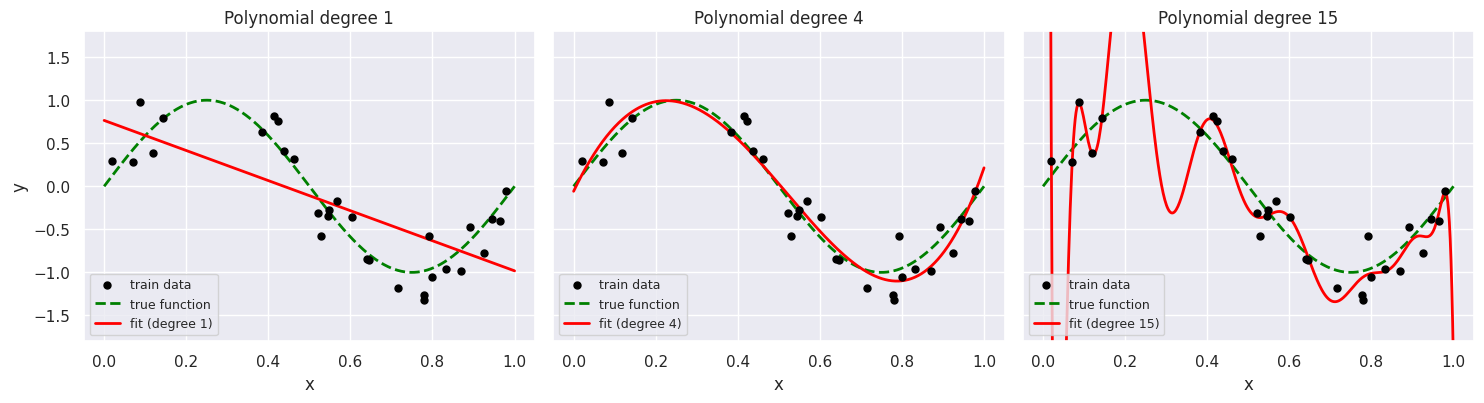

In [ ]:
# Step 1-2: noisy training data + fits at three polynomial degrees
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

# True (unknown to the model) function we are trying to learn
def true_fn(x):
    return np.sin(2 * np.pi * x)

# A single small, noisy training set
rng = np.random.RandomState(0)
n_train = 30
x_train = np.sort(rng.uniform(0, 1, n_train))
y_train = true_fn(x_train) + rng.normal(0, 0.2, n_train)

x_grid  = np.linspace(0, 1, 500)
y_truth = true_fn(x_grid)

# Three increasing complexities
degrees = [1, 4, 15]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, d in zip(axes, degrees):
    model = make_pipeline(PolynomialFeatures(d), LinearRegression())
    model.fit(x_train[:, None], y_train)
    y_pred = model.predict(x_grid[:, None])

    ax.scatter(x_train, y_train, color='black', s=25, zorder=3, label='train data')
    ax.plot(x_grid, y_truth, '--', color='green', linewidth=2, label='true function')
    ax.plot(x_grid, y_pred,  color='red',   linewidth=2, label=f'fit (degree {d})')
    ax.set_title(f'Polynomial degree {d}')
    ax.set_ylim(-1.8, 1.8)
    ax.set_xlabel('x')
    ax.legend(loc='lower left', fontsize=9)
axes[0].set_ylabel('y')
plt.tight_layout()
plt.show()


- **Degree 1 (left)** — a straight line cannot bend to follow the sine, so the red fit is systematically off the green curve almost everywhere. This is **high bias / underfit**.
- **Degree 4 (middle)** — flexible enough to track the true sine curve closely without chasing every noisy point. This is the **sweet spot**.
- **Degree 15 (right)** — the polynomial has so many free parameters that it bends to fit individual noisy points, producing wild swings between them. This is **high variance / overfit**.

Visually convincing, but a single fit only shows us *one* training set. To **see variance directly**, we need to refit on many different training sets and look at how much the fits move.


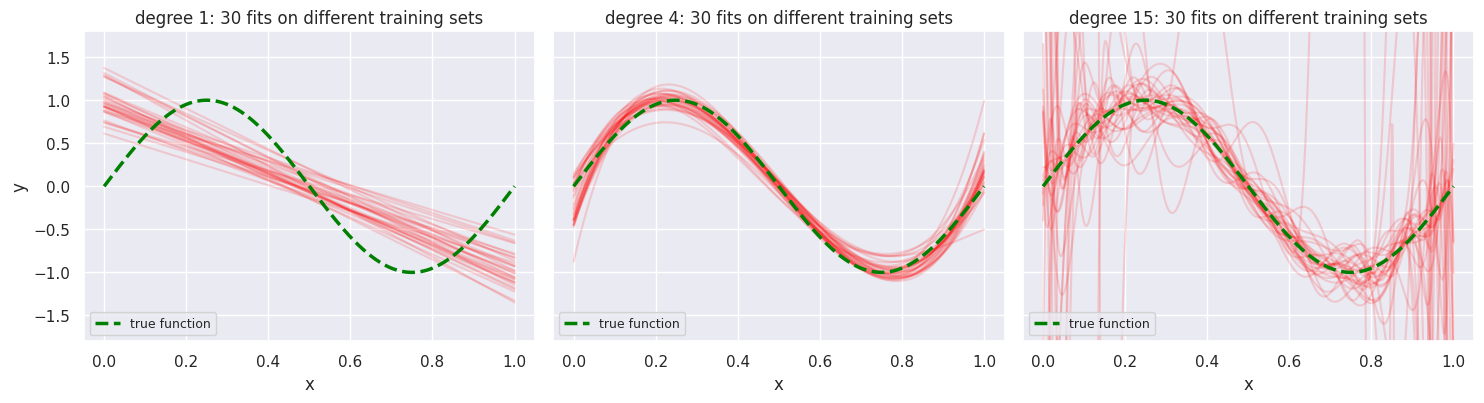

In [ ]:
# Step 3: refit each polynomial degree on many resampled training sets
n_resamples = 30
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, d in zip(axes, degrees):
    # Draw n_resamples independent training sets from the same noisy process
    for seed in range(n_resamples):
        rs = np.random.RandomState(seed)
        x_s = np.sort(rs.uniform(0, 1, n_train))
        y_s = true_fn(x_s) + rs.normal(0, 0.2, n_train)

        model = make_pipeline(PolynomialFeatures(d), LinearRegression())
        model.fit(x_s[:, None], y_s)
        ax.plot(x_grid, model.predict(x_grid[:, None]),
                color='red', alpha=0.15)
    ax.plot(x_grid, y_truth, '--', color='green', linewidth=2.5,
            label='true function', zorder=3)
    ax.set_title(f'degree {d}: {n_resamples} fits on different training sets')
    ax.set_ylim(-1.8, 1.8)
    ax.set_xlabel('x')
    ax.legend(loc='lower left', fontsize=9)
axes[0].set_ylabel('y')
plt.tight_layout()
plt.show()


Now bias and variance are visible as actual quantities on the plot:

- **Degree 1 (left)**: the 30 red fits are almost on top of each other — *low variance* — but they all sit far from the green curve — *high bias*.
- **Degree 4 (middle)**: the red fits are both tightly clustered **and** close to the green curve — *low bias, low variance*. This is what we want.
- **Degree 15 (right)**: every red fit is wildly different from the others — *high variance* — even though, on average, they roughly track the sine curve — *low bias*.

This matches the dartboard picture from the slide exactly. Now let's see the same story as numbers.


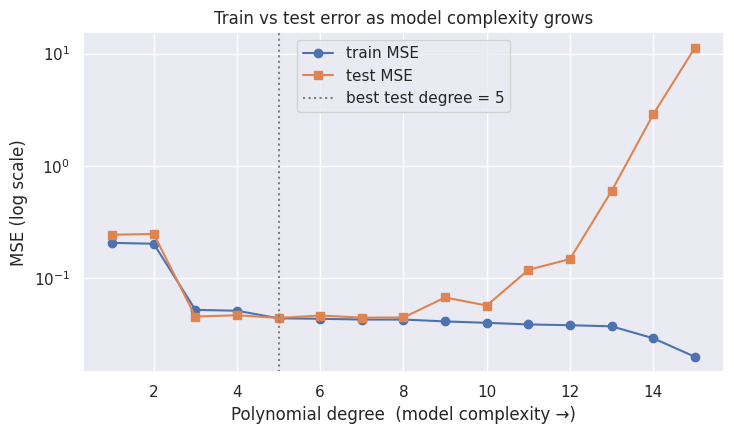

In [ ]:
# Step 4: train and test MSE as polynomial degree grows -> the classic U-curve
from sklearn.metrics import mean_squared_error

# Held-out test set drawn from the same noisy process
rng_test = np.random.RandomState(42)
x_test = np.sort(rng_test.uniform(0, 1, 200))
y_test = true_fn(x_test) + rng_test.normal(0, 0.2, 200)

degree_range = list(range(1, 16))
train_mse, test_mse = [], []
for d in degree_range:
    model = make_pipeline(PolynomialFeatures(d), LinearRegression())
    model.fit(x_train[:, None], y_train)
    train_mse.append(mean_squared_error(y_train, model.predict(x_train[:, None])))
    test_mse.append( mean_squared_error(y_test,  model.predict(x_test[:,  None])))

best_d = degree_range[int(np.argmin(test_mse))]
plt.figure(figsize=(7.5, 4.5))
plt.plot(degree_range, train_mse, marker='o', label='train MSE')
plt.plot(degree_range, test_mse,  marker='s', label='test MSE')
plt.axvline(best_d, color='gray', linestyle=':', label=f'best test degree = {best_d}')
plt.xlabel('Polynomial degree  (model complexity →)')
plt.ylabel('MSE (log scale)')
plt.yscale('log')
plt.title('Train vs test error as model complexity grows')
plt.legend()
plt.tight_layout()
plt.show()


The two curves tell the bias-variance story numerically:

- **Train MSE (blue circles)** falls monotonically. A more flexible model can always fit the *training* data better — eventually exactly.
- **Test MSE (orange squares)** has a clear **U-shape**: it falls as the model stops underfitting, hits a minimum somewhere in the middle (around degree 4-5), and then climbs again as the model starts memorizing noise.

The minimum of the test curve is the **best bias-variance compromise** for this problem.

**Linking back to ensembling.** If we are stuck with a high-variance model (a fit on the right side of the U), **bagging** averages many resamples of it and effectively pulls the red lines from the right-most panel of the previous figure toward their mean — reducing variance without changing average bias. If we are stuck with a high-bias model (left side of the U), **boosting** keeps fitting the residuals and steadily pulls the average fit toward the true curve — reducing bias. Each ensembling family attacks one side of the tradeoff.


### 5.9 Section summary

| Family            | Algorithm               | When to use                                                                     | Notes                                                  |
|-------------------|-------------------------|---------------------------------------------------------------------------------|--------------------------------------------------------|
| **Bagging**       | RandomForest            | When over-learning is to be avoided; good early-stage baseline                  | First option among bagging methods                     |
|                   | BaggingClassifier / Regressor | When you want bagging with a non-tree base learner                          | Apply to k-NN, LogReg, etc.                            |
| **Boosting**      | **XGBoost**, GradientBoosting | When you want to push accuracy; once useful features are identified         | First choice in many cases                             |
|                   | AdaBoost                | Classic boosting variant                                                        |                                                        |
| **No ensembling** | Standalone model        | When **interpretability of results matters** (e.g. a single decision tree is much easier to explain) | A linear model or single tree is often clearer        |

> **[Let’s try it — Bias-Variance]**
> Train a `DecisionTreeRegressor` on the California Housing data with `max_depth ∈ {1, 3, 5, 10, None}`. Plot train R² and test R² as a function of `max_depth`. Identify the regime where bias dominates (left side) vs where variance dominates (right side).


## 6. Key Takeaways

- **Feature engineering can hugely impact a model’s performance.**
  - *Feature transformation*: standardization, normalization, log, encoding.
  - *Feature creation*: combine existing features, use domain knowledge.
- **Feature engineering is iterative.** Expect several trial-and-error loops between feature design and model evaluation.
- **Ensembling is very useful in real-world applications.**
  - **Bagging** (e.g. Random Forest) reduces variance.
  - **Boosting** (e.g. AdaBoost, XGBoost, LightGBM) reduces bias and is the first choice for pushing accuracy.


**Acknowledgments:**<br>
The following datasets were used under the following terms:
1. http://lib.stat.cmu.edu/datasets/boston

Reference: The Boston house-price data of Harrison, D. and Rubinfeld, D.L. 'Hedonic prices and the demand for clean air', J. Environ. Economics & Management, vol.5, 81-102, 1978. Used in Belsley, Kuh & Welsch, 'Regression Diagnostics: Identifying Influential Data and Sources of Collinearity', Wiley, 1980.